### Preparacion de Ambiente 

In [4]:
# Data Wrangling
import numpy as np
import pandas as pd
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import loguniform, uniform,randint



# Preprocessing
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Modeling
from sklearn.svm import SVC, SVR
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import RobustScaler

# Model performance
from sklearn.metrics import accuracy_score, confusion_matrix,recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
 
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.calibration import CalibratedClassifierCV


import pickle
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
import os
print(os.getcwd())


/home/eduardo-castillo/Documentos/diplomado/repositorio/Diplomado_DataSciene/practicas/Modulo_II/P3


## Funciones Auxiliares 

In [6]:
def normalizar_columnas(df):
    

    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .map(lambda x: unicodedata.normalize('NFKD', x)
             .encode('ascii', 'ignore')
             .decode('utf-8'))
        .str.replace(r'[^a-z0-9_ ]', '', regex=True)
        .str.replace(' ', '_')
    )
    for col in df.select_dtypes(include='object').columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(lambda x: unicodedata.normalize('NFKD', x)
                 .encode('ascii', 'ignore')
                 .decode('utf-8'))
        )

    return df


In [7]:
def freq_discrete(df, features):
    """
    Calcula y muestra tablas de frecuencias absolutas, relativas y acumuladas para variables categóricas.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame que contiene las variables a analizar.
    features : list of str
        Lista con los nombres de las columnas categóricas a analizar.

    Descripción
    -----------
    Para cada variable en `features`, imprime su nombre y muestra una tabla con:
      - Frecuencia absoluta de cada categoría.
      - Frecuencia relativa (porcentaje) de cada categoría.
      - Frecuencia absoluta acumulada.
      - Frecuencia relativa acumulada.
    Los valores se formatean para mejor visualización.

    Ejemplo
    -------
    freq_discrete(df, ["color", "country"])
    """
    for feature in features:
        print(f"Feature: {feature}")
        abs_series = df[feature].value_counts(dropna=False)
        rel_series = df[feature].value_counts(dropna=False, normalize=True)
        freq = pd.DataFrame({"Absolute frequency": abs_series, "Relative frequency": rel_series})
        freq["Accumulated frequency"] = freq["Absolute frequency"].cumsum()
        freq["Accumulated %"] = freq["Relative frequency"].cumsum()
        freq["Absolute frequency"] = freq["Absolute frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Relative frequency"] = freq["Relative frequency"].map(lambda x: "{:,.2%}".format(x))
        freq["Accumulated frequency"] = freq["Accumulated frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Accumulated %"] = freq["Accumulated %"].map(lambda x: "{:,.2%}".format(x))
        display(freq)

In [8]:
def evaluar_y_graficar_modelos(resultados_dict, X_train, y_train, X_test, y_test):
    """
    Evalúa múltiples modelos, genera un DataFrame de métricas y visualiza 
    la comparativa de generalización (Train vs Test).
    """
    res_list = []

    for nombre, info in resultados_dict.items():
        modelo = info['objeto']
        
        # Diccionario temporal para guardar predicciones y datos
        data_eval = [
            ('Train', X_train, y_train),
            ('Test', X_test, y_test)
        ]
        
        for set_name, X_set, y_true in data_eval:
            # Predicciones de clase
            y_pred = modelo.predict(X_set)
            
            # Probabilidades para ROC-AUC
            if hasattr(modelo, "predict_proba"):
                y_prob = modelo.predict_proba(X_set)[:, 1]
            else:
                y_prob = modelo.decision_function(X_set)
            
            # Guardar métricas
            res_list.append({
                'Modelo': nombre,
                'Set': set_name,
                'Accuracy': accuracy_score(y_true, y_pred),
                'Recall': recall_score(y_true, y_pred),
                'F1-Score': f1_score(y_true, y_pred),
                'ROC-AUC': roc_auc_score(y_true, y_prob)
            })

    # Crear DataFrame
    df_res = pd.DataFrame(res_list)

    # --- VISUALIZACIÓN ---
    # Transformar a formato largo para Seaborn
    df_melt = df_res.melt(id_vars=['Modelo', 'Set'], var_name='Metrica', value_name='Score')

    sns.set_style("whitegrid")
    g = sns.catplot(
        data=df_melt, kind="bar",
        x="Modelo", y="Score", hue="Set",
        col="Metrica", col_wrap=2,
        palette={"Train": "#3498db", "Test": "#e67e22"},
        height=4, aspect=1.5
    )

    # Personalización de títulos y etiquetas
    g.fig.suptitle('Evaluación de Modelos: Comparativa Train vs Test', fontsize=18, y=1.05)
    g.set_titles("{col_name}")
    
    # Añadir valores sobre las barras
    for ax in g.axes.flat:
        for p in ax.patches:
            ax.annotate(format(p.get_height(), '.2f'), 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        xytext=(0, 9), 
                        textcoords='offset points', fontsize=10)
    
    plt.show()
    
    # Retornar el DataFrame para usarlo en el ranking
    return df_res



## EDA

In [9]:
""" 
Diccionario de datos:
ID: ID of each client
LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit
SEX: Gender (1=male, 2=female)
EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)
MARRIAGE: Marital status (1=married, 2=single, 3=others)
AGE: Age in years
PAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)
PAY_2: Repayment status in August, 2005 (scale same as above)
PAY_3: Repayment status in July, 2005 (scale same as above)
PAY_4: Repayment status in June, 2005 (scale same as above)
PAY_5: Repayment status in May, 2005 (scale same as above)
PAY_6: Repayment status in April, 2005 (scale same as above)
BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)
BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)
BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)
BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)
BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)
BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)
PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)
PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)
PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)
PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)
PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)
PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)
default.payment.next.month: Default payment (1=yes, 0=no)
"""


' \nDiccionario de datos:\nID: ID of each client\nLIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit\nSEX: Gender (1=male, 2=female)\nEDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)\nMARRIAGE: Marital status (1=married, 2=single, 3=others)\nAGE: Age in years\nPAY_0: Repayment status in September, 2005 (-1=pay duly, 1=payment delay for one month, 2=payment delay for two months, … 8=payment delay for eight months, 9=payment delay for nine months and above)\nPAY_2: Repayment status in August, 2005 (scale same as above)\nPAY_3: Repayment status in July, 2005 (scale same as above)\nPAY_4: Repayment status in June, 2005 (scale same as above)\nPAY_5: Repayment status in May, 2005 (scale same as above)\nPAY_6: Repayment status in April, 2005 (scale same as above)\nBILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)\nBILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)\nBILL_A

In [10]:
""" 
Apartir del diccionario podemos deducir lo siguiente 
## Variables Categoricas

    SEX: (1=Hombre, 2=Mujer).

    MARRIAGE: (1=casado, 2=soltero, 3=otros).

    EDUCATION: (1 a 4 principales, 5-6 desconocidos).


Variables Discretas Ordinales (Historial de Pago):
    Estas son discretas porque tienen pocos valores, pero sí tienen un orden (un 2 es peor que un 1).

    PAY_0 a PAY_6: El número representa meses de retraso.

                    Valores negativos (-1, -2): Significan que el cliente pagó a tiempo o por adelantado.

Variables Continuas (Métricas de Valor):
    Son las variables que miden cantidades de dinero o tiempo.

        LIMIT_BAL: El monto del crédito.

        AGE: Edad del cliente.

        BILL_AMT1 a BILL_AMT6: Lo que deben en su estado de cuenta.

        PAY_AMT1 a PAY_AMT6: Lo que pagaron efectivamente.

        
        default.payment.next.month: Default payment Es nuestra variable objetivo 

        id es nuestro identificador 
"""

' \nApartir del diccionario podemos deducir lo siguiente \n## Variables Categoricas\n\n    SEX: (1=Hombre, 2=Mujer).\n\n    MARRIAGE: (1=casado, 2=soltero, 3=otros).\n\n    EDUCATION: (1 a 4 principales, 5-6 desconocidos).\n\n\nVariables Discretas Ordinales (Historial de Pago):\n    Estas son discretas porque tienen pocos valores, pero sí tienen un orden (un 2 es peor que un 1).\n\n    PAY_0 a PAY_6: El número representa meses de retraso.\n\n                    Valores negativos (-1, -2): Significan que el cliente pagó a tiempo o por adelantado.\n\nVariables Continuas (Métricas de Valor):\n    Son las variables que miden cantidades de dinero o tiempo.\n\n        LIMIT_BAL: El monto del crédito.\n\n        AGE: Edad del cliente.\n\n        BILL_AMT1 a BILL_AMT6: Lo que deben en su estado de cuenta.\n\n        PAY_AMT1 a PAY_AMT6: Lo que pagaron efectivamente.\n\n\n        default.payment.next.month: Default payment Es nuestra variable objetivo \n\n        id es nuestro identificador \n'

In [11]:
train=pd.read_csv(r'train_p3.csv')
## Normalizamos el dataset
train=normalizar_columnas(train)
train.rename(columns={'default payment next month': 'target'}, inplace=True)
train.head()


,id,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
0,18125,220000,2,3,2,32,0,0,0,0,...,171391,178742,164793,7000,15000,6000,10000,10000,7000,0
1,3983,220000,2,2,1,41,2,0,0,2,...,29579,48933,97187,1465,3009,0,20000,50000,1240,0
2,19251,80000,2,1,2,27,-1,-1,-1,0,...,917,702,3099,1325,917,0,702,3099,0,0
3,4024,20000,2,2,2,38,1,2,2,4,...,14190,13721,13848,2500,2501,0,0,441,1,0
4,20610,100000,2,1,2,28,0,0,0,0,...,100999,101188,99328,4600,4000,4000,4000,4000,4400,0


In [12]:
## Valores Unicos 
# Ver cuántos valores únicos tiene cada columna realmente
for col in train.columns:
    print(f"{col}: {train[col].nunique()} valores únicos")

id: 21000 valores únicos
limit_bal: 79 valores únicos
sex: 2 valores únicos
education: 7 valores únicos
marriage: 4 valores únicos
age: 55 valores únicos
pay_0: 11 valores únicos
pay_2: 11 valores únicos
pay_3: 11 valores únicos
pay_4: 11 valores únicos
pay_5: 10 valores únicos
pay_6: 10 valores únicos
bill_amt1: 16589 valores únicos
bill_amt2: 16314 valores únicos
bill_amt3: 16106 valores únicos
bill_amt4: 15806 valores únicos
bill_amt5: 15477 valores únicos
bill_amt6: 15114 valores únicos
pay_amt1: 6373 valores únicos
pay_amt2: 6364 valores únicos
pay_amt3: 6012 valores únicos
pay_amt4: 5585 valores únicos
pay_amt5: 5486 valores únicos
pay_amt6: 5534 valores únicos
default_payment_next_month: 2 valores únicos


In [13]:
freq_discrete(train,train.columns)

Feature: id


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
id,,,,
16728,1,0.00%,1,0.00%
18125,1,0.00%,2,0.01%
3983,1,0.00%,3,0.01%
19251,1,0.00%,4,0.02%
4024,1,0.00%,5,0.02%
...,...,...,...,...
26689,1,0.00%,"20,996",99.98%
28758,1,0.00%,"20,997",99.99%
24470,1,0.00%,"20,998",99.99%


Feature: limit_bal


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
limit_bal,,,,
50000,"2,342",11.15%,"2,342",11.15%
20000,"1,373",6.54%,"3,715",17.69%
30000,"1,138",5.42%,"4,853",23.11%
200000,"1,109",5.28%,"5,962",28.39%
80000,"1,092",5.20%,"7,054",33.59%
...,...,...,...,...
690000,1,0.00%,"20,996",99.98%
740000,1,0.00%,"20,997",99.99%
760000,1,0.00%,"20,998",99.99%


Feature: sex


...

,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
pay_amt5,,,,
0,"4,698",22.37%,"4,698",22.37%
1000,926,4.41%,"5,624",26.78%
2000,918,4.37%,"6,542",31.15%
3000,670,3.19%,"7,212",34.34%
5000,586,2.79%,"7,798",37.13%
...,...,...,...,...
2261,1,0.00%,"20,996",99.98%
17914,1,0.00%,"20,997",99.99%
7532,1,0.00%,"20,998",99.99%


Feature: pay_amt6


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
pay_amt6,,,,
0,"5,026",23.93%,"5,026",23.93%
2000,901,4.29%,"5,927",28.22%
1000,888,4.23%,"6,815",32.45%
3000,614,2.92%,"7,429",35.38%
5000,593,2.82%,"8,022",38.20%
...,...,...,...,...
39268,1,0.00%,"20,996",99.98%
7006,1,0.00%,"20,997",99.99%
2595,1,0.00%,"20,998",99.99%


Feature: default_payment_next_month


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
default_payment_next_month,,,,
0,"16,445",78.31%,"16,445",78.31%
1,"4,555",21.69%,"21,000",100.00%


In [14]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          21000 non-null  int64
 1   limit_bal                   21000 non-null  int64
 2   sex                         21000 non-null  int64
 3   education                   21000 non-null  int64
 4   marriage                    21000 non-null  int64
 5   age                         21000 non-null  int64
 6   pay_0                       21000 non-null  int64
 7   pay_2                       21000 non-null  int64
 8   pay_3                       21000 non-null  int64
 9   pay_4                       21000 non-null  int64
 10  pay_5                       21000 non-null  int64
 11  pay_6                       21000 non-null  int64
 12  bill_amt1                   21000 non-null  int64
 13  bill_amt2                   21000 non-null  int64
 14  bill_a

In [15]:
train.isna().sum()

id                            0
limit_bal                     0
sex                           0
education                     0
marriage                      0
age                           0
pay_0                         0
pay_2                         0
pay_3                         0
pay_4                         0
pay_5                         0
pay_6                         0
bill_amt1                     0
bill_amt2                     0
bill_amt3                     0
bill_amt4                     0
bill_amt5                     0
bill_amt6                     0
pay_amt1                      0
pay_amt2                      0
pay_amt3                      0
pay_amt4                      0
pay_amt5                      0
pay_amt6                      0
default_payment_next_month    0
dtype: int64

In [16]:
train.isnull().sum()

id                            0
limit_bal                     0
sex                           0
education                     0
marriage                      0
age                           0
pay_0                         0
pay_2                         0
pay_3                         0
pay_4                         0
pay_5                         0
pay_6                         0
bill_amt1                     0
bill_amt2                     0
bill_amt3                     0
bill_amt4                     0
bill_amt5                     0
bill_amt6                     0
pay_amt1                      0
pay_amt2                      0
pay_amt3                      0
pay_amt4                      0
pay_amt5                      0
pay_amt6                      0
default_payment_next_month    0
dtype: int64

In [17]:
#En Educación, los valores 0, 5 y 6 los pasamos a 4 (que es 'Otros' o 'Unknown')
train['education'] = train['education'].replace([0, 5, 6], 4)

#En Matrimonio, el valor 0 lo pasamos a 3 (que es 'Otros')
train['marriage'] = train['marriage'].replace(0, 3)

/tmp/ipykernel_10686/1777024837.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=train[col], x=train['default_payment_next_month'], palette='Set2')
/tmp/ipykernel_10686/1777024837.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=train[col], x=train['default_payment_next_month'], palette='Set2')
/tmp/ipykernel_10686/1777024837.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=train[col], x=train['default_payment_next_month'], palette='Set2')
/tmp/ipykernel_10686/1777024837.py:9: FutureWarning: 

Passing `palette` without assigni

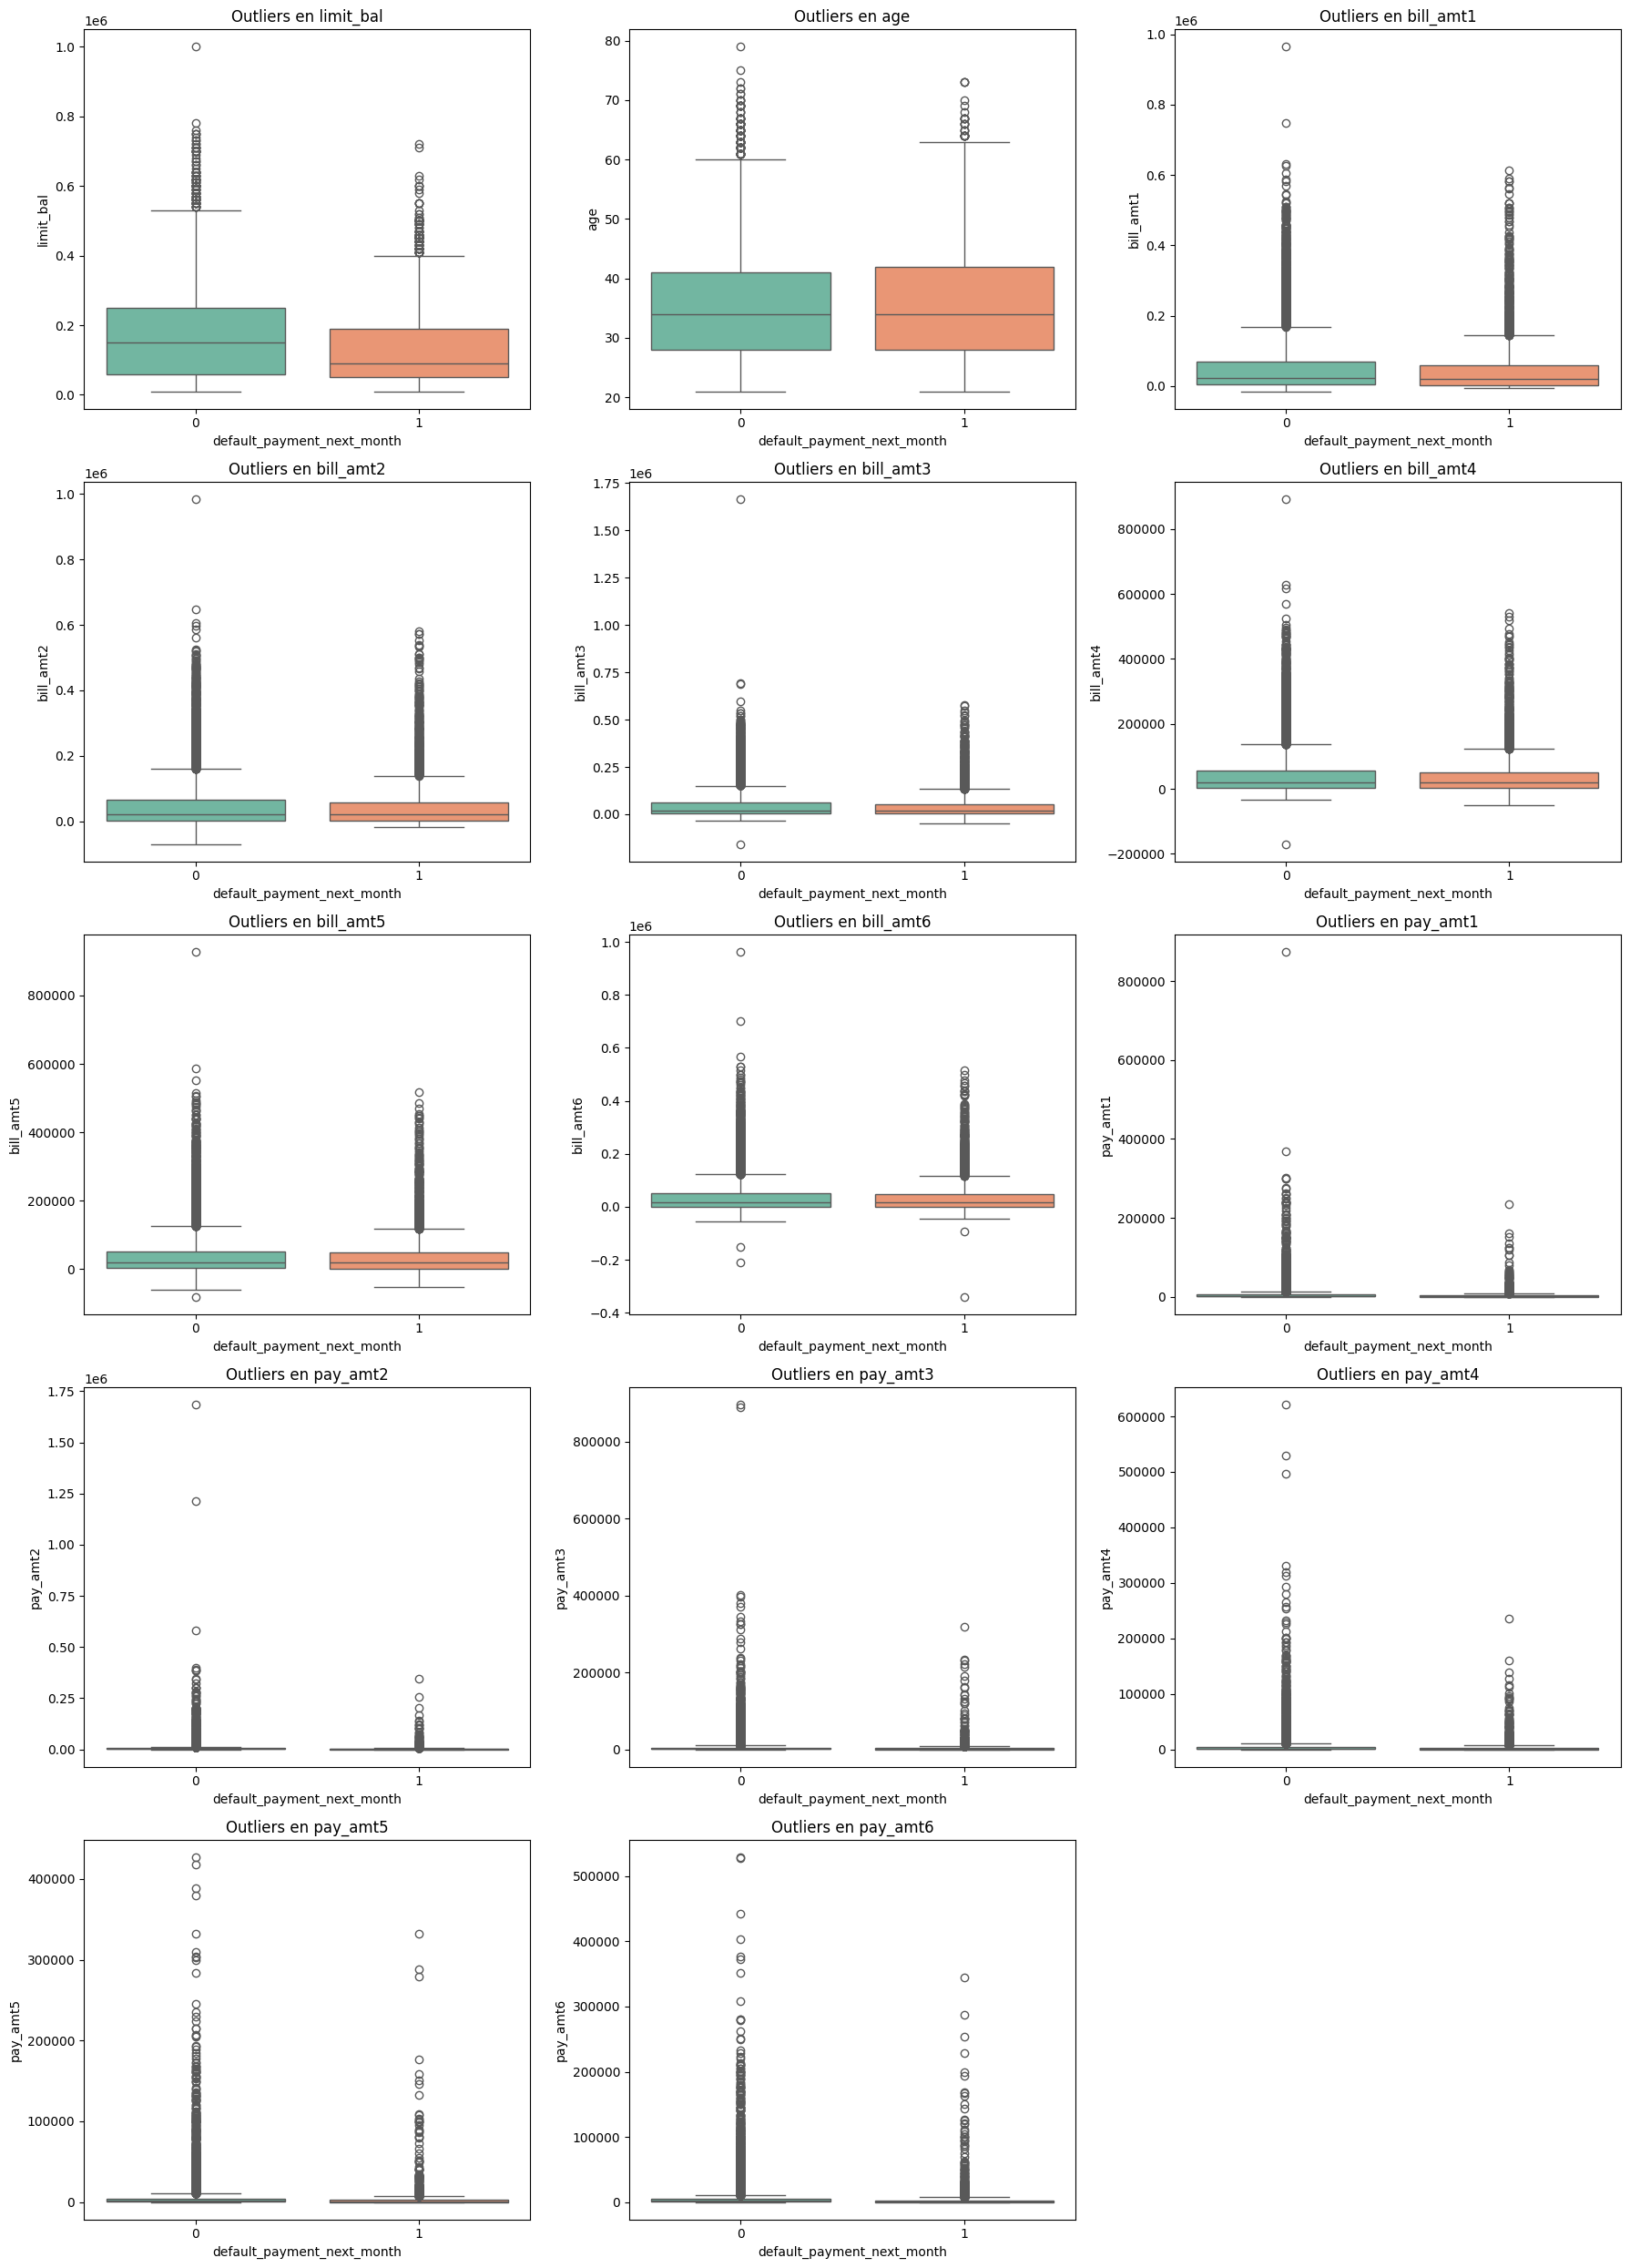

In [18]:
cols = ['limit_bal', 'age', 'bill_amt1', 'bill_amt2','bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1',
               'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols 

plt.figure(figsize=(18, 5 * n_rows)) #
for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=train[col], x=train['default_payment_next_month'], palette='Set2')
    plt.title(f'Outliers en {col}')
plt.tight_layout()
plt.show()

In [19]:
train.columns

Index(['id', 'limit_bal', 'sex', 'education', 'marriage', 'age', 'pay_0',
       'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2',
       'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1',
       'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
       'default_payment_next_month'],
      dtype='object')

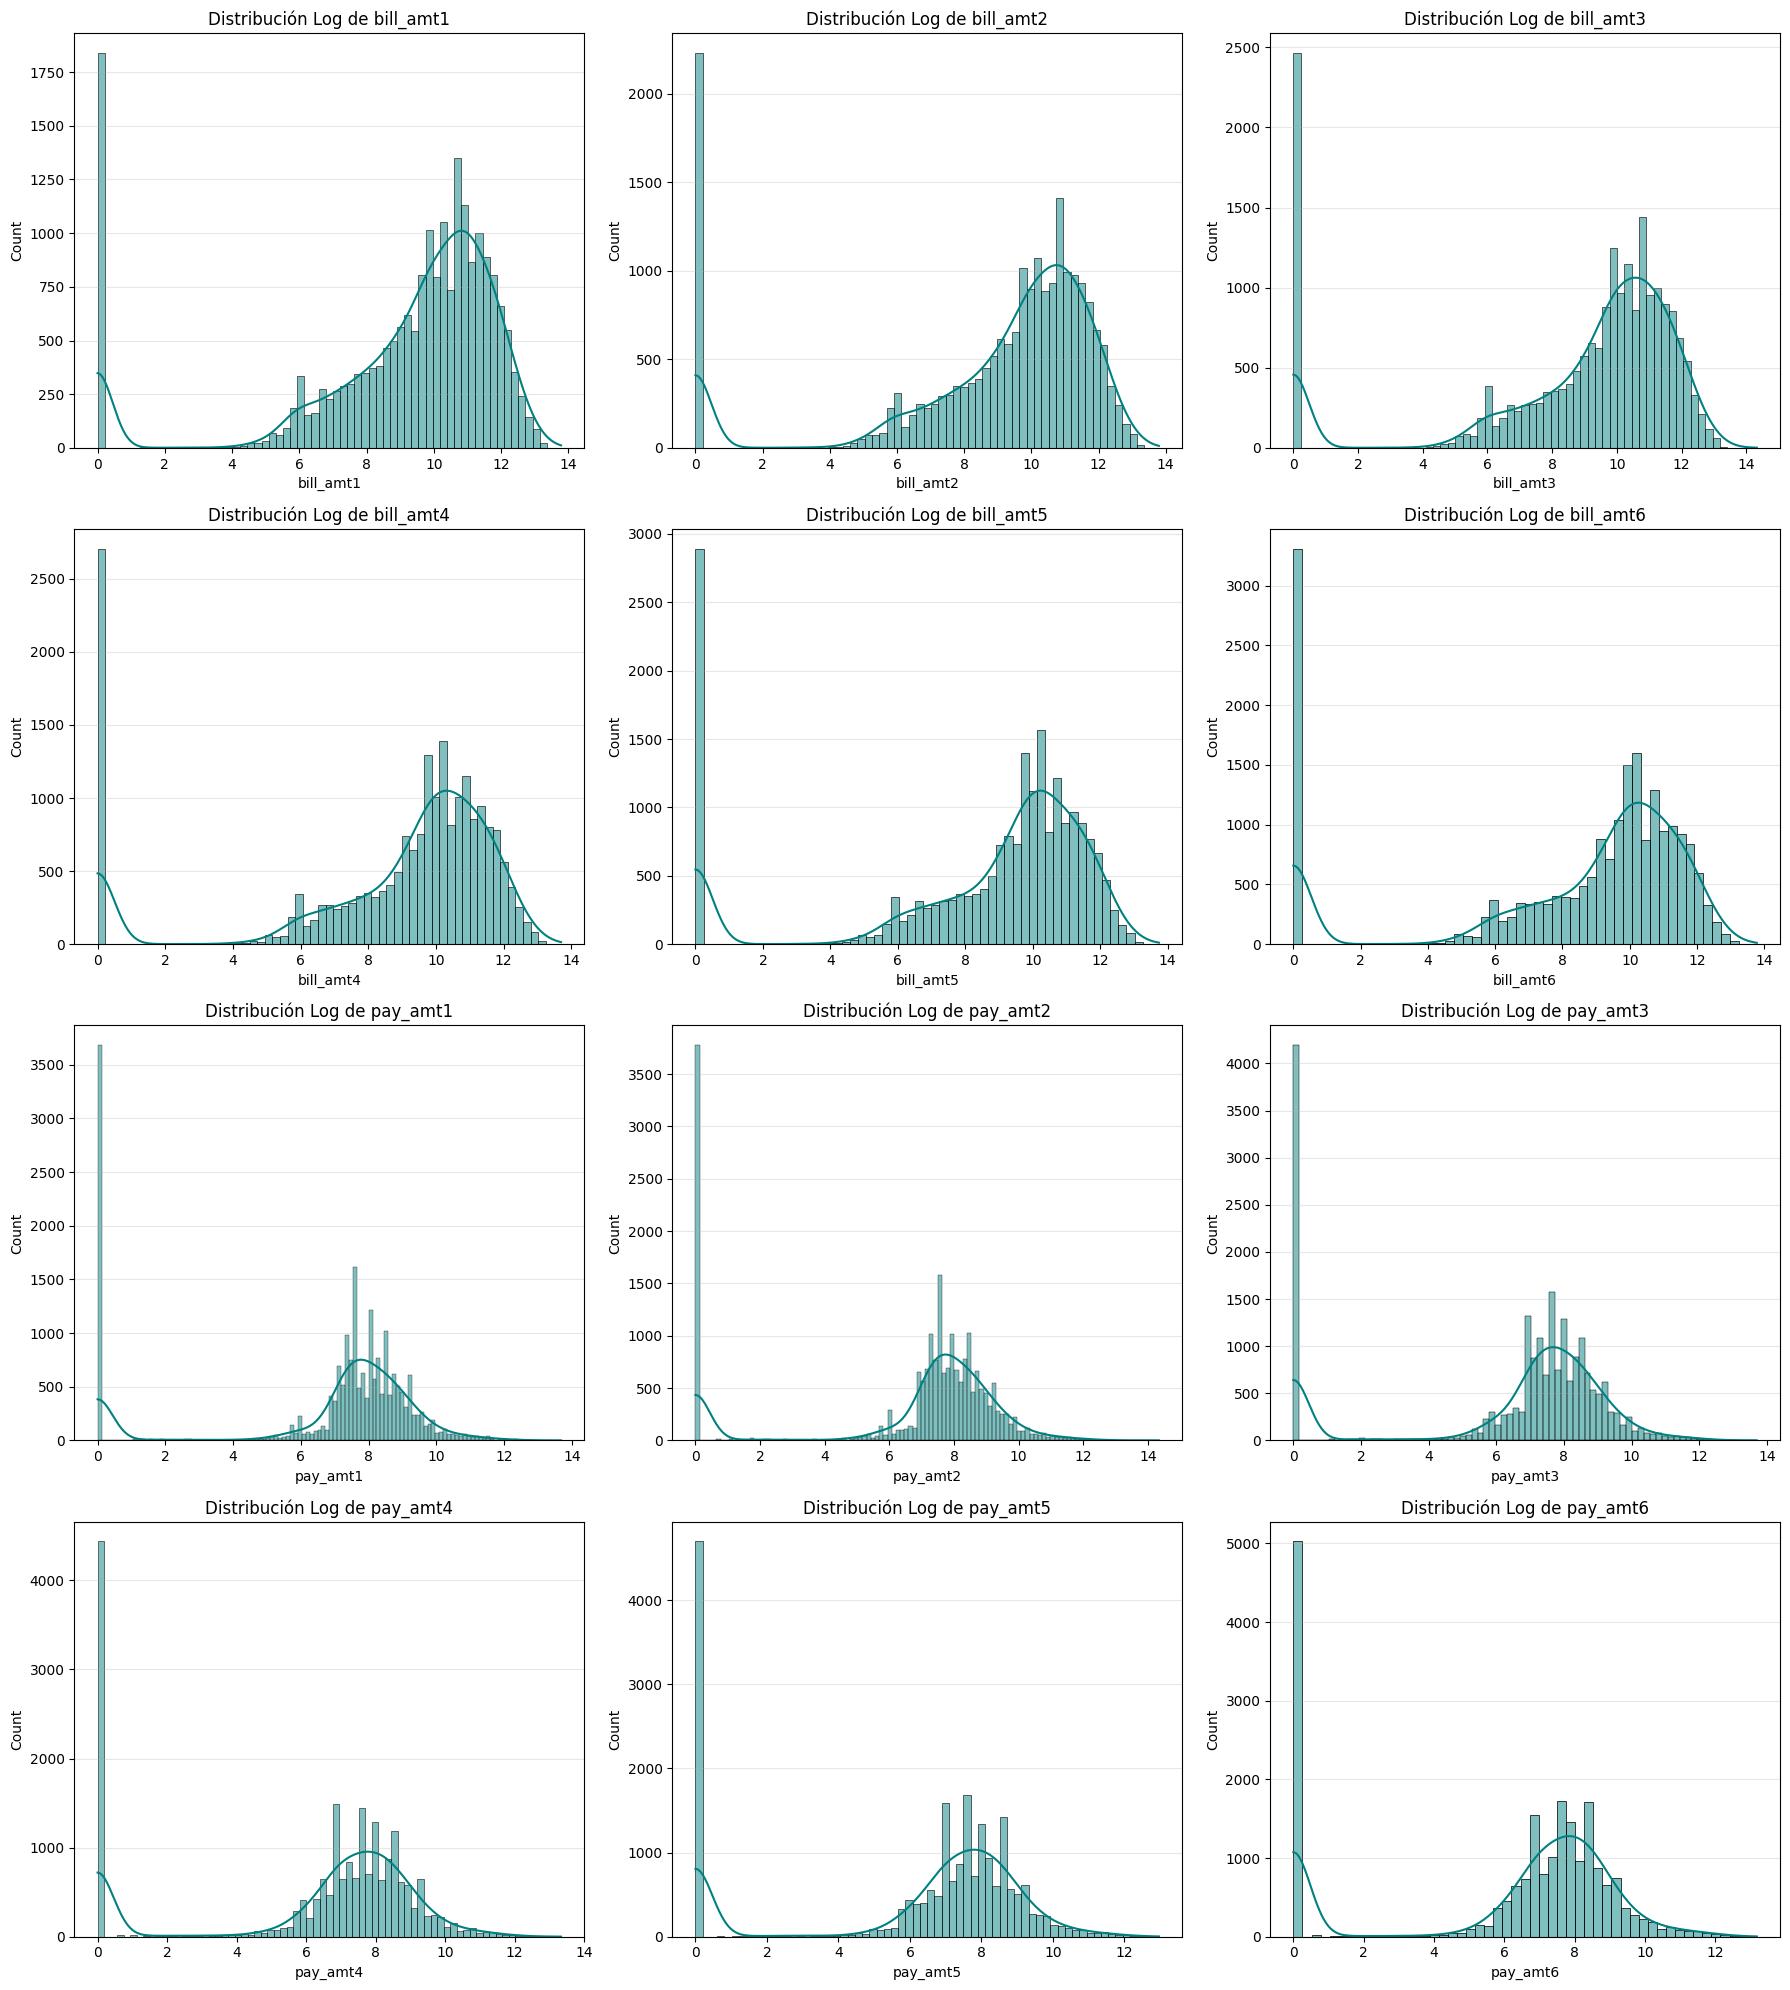

In [20]:
# --- 3. Análisis de Variables "Flat" (Sesgadas) ---
# Las variables de pago (PAY_AMT) suelen verse "planas" porque la mayoría está cerca de 0.
# Usamos transformación logarítmica para ver la distribución real.
# Lista de variables de pago
pay_amt_cols = ['bill_amt1', 'bill_amt2','bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1',
               'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']

# Calculamos filas necesarias para 3 columnas
n_cols = 3
n_rows = (len(pay_amt_cols) + n_cols - 1) // n_cols 

plt.figure(figsize=(18, 5 * n_rows)) #
for i, col in enumerate(pay_amt_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(np.log1p(train[col].clip(lower=0)), kde=True, color='teal')
    
    plt.title(f'Distribución Log de {col}')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
### Como podemos observar muchos clientes tuvieron dificultad de pago, Esto significa que el riesgo de no pagar no es algo que le pase a todos por igual, sino que está muy marcado en los clientes que dejan de tener actividad.

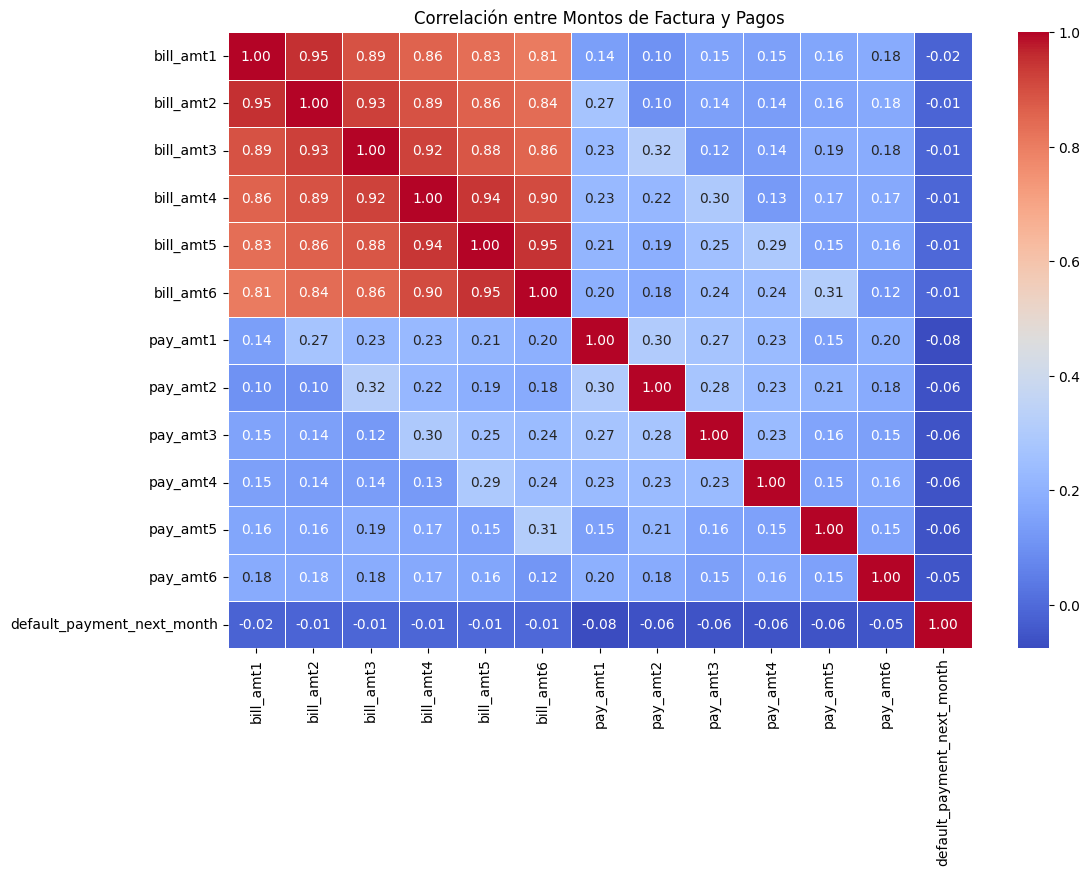

In [22]:
# Seleccionamos las familias de variables
bill_cols = [f'bill_amt{i}' for i in range(1, 7)]
pay_cols = [f'pay_amt{i}' for i in range(1, 7)]
target = 'default_payment_next_month' 
# Creamos una matriz solo con estas variables
f_cols = bill_cols + pay_cols + [target]
corr_family = train[f_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_family, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlación entre Montos de Factura y Pagos')
plt.show()

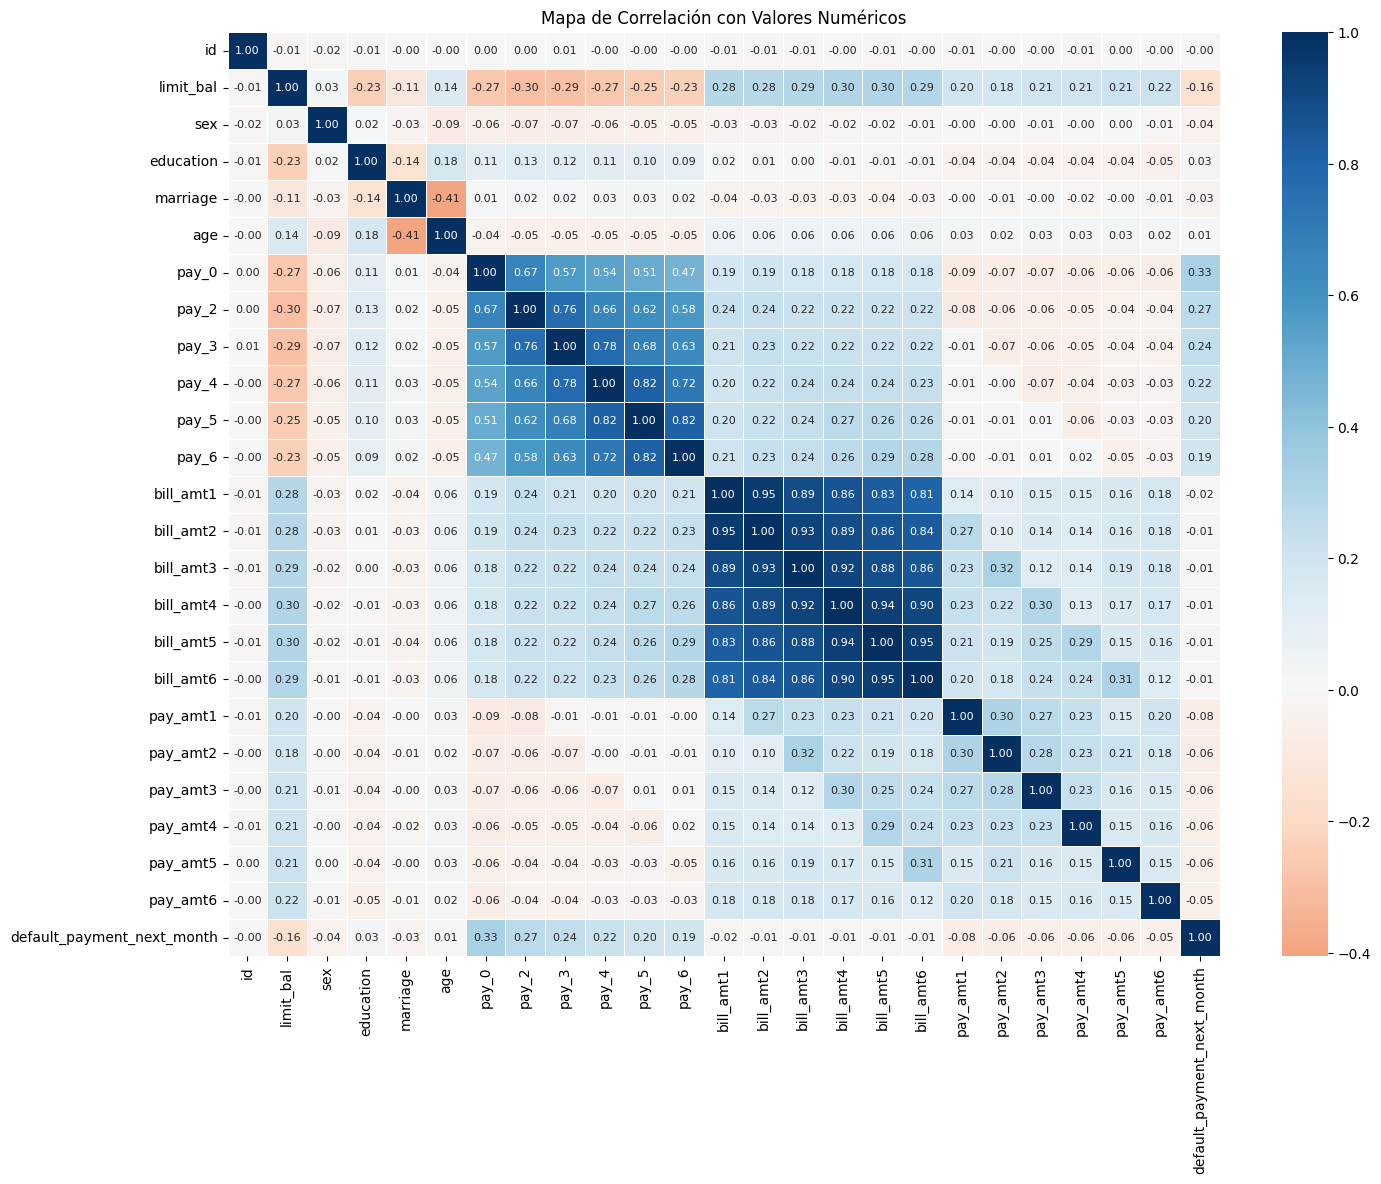

In [23]:

plt.figure(figsize=(16, 12)) 
corr_matrix = train.corr()

# Dibujamos el heatmap
sns.heatmap(corr_matrix,cmap='RdBu', center=0,annot=True,fmt=".2f",annot_kws={"size": 8},linewidths=0.5)  

plt.title('Mapa de Correlación con Valores Numéricos')
plt.show()

In [24]:
"""la matriz nos dice que hay mucha información repetida en las facturas mensuales y que el mejor dato para predecir el futuro es el comportamiento de pago más reciente. 
Los datos personales (edad, sexo) casi no influyen, así que el modelo debería enfocarse en el historial de pagos para ser preciso."""

'la matriz nos dice que hay mucha información repetida en las facturas mensuales y que el mejor dato para predecir el futuro es el comportamiento de pago más reciente. \nLos datos personales (edad, sexo) casi no influyen, así que el modelo debería enfocarse en el historial de pagos para ser preciso.'

### Tratamiento de Outliers

In [25]:
"""
Para el tratamiento de outliers, se decidió no eliminar registros de forma masiva para no perder información de clientes con altos montos de facturación. 
En su lugar, se optó por una transformación logarítmica y el uso de un RobustScaler, el cual utiliza la mediana y los cuartiles para normalizar los datos, 
siendo mucho más resistente a los valores extremos que el escalamiento tradicional.
"""


'\nPara el tratamiento de outliers, se decidió no eliminar registros de forma masiva para no perder información de clientes con altos montos de facturación. \nEn su lugar, se optó por una transformación logarítmica y el uso de un RobustScaler, el cual utiliza la mediana y los cuartiles para normalizar los datos, \nsiendo mucho más resistente a los valores extremos que el escalamiento tradicional.\n'

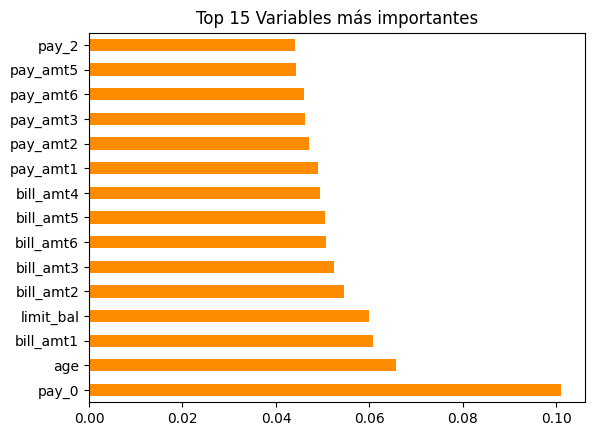

In [26]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel


# Separamos X y y
X = train.drop(['id', 'default_payment_next_month'], axis=1) 
y = train['default_payment_next_month']

# Entrenamos un modelo rápido
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Graficamos la importancia
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(15).plot(kind='barh', color='darkorange')
plt.title('Top 15 Variables más importantes')
plt.show()

In [27]:
importances.head(25)

limit_bal    0.059996
sex          0.011783
education    0.019523
marriage     0.013499
age          0.065613
pay_0        0.101057
pay_2        0.043977
pay_3        0.025822
pay_4        0.024727
pay_5        0.018321
pay_6        0.021083
bill_amt1    0.060822
bill_amt2    0.054551
bill_amt3    0.052435
bill_amt4    0.049436
bill_amt5    0.050448
bill_amt6    0.050812
pay_amt1     0.049002
pay_amt2     0.047012
pay_amt3     0.046249
pay_amt4     0.043687
pay_amt5     0.044230
pay_amt6     0.045915
dtype: float64

In [28]:

# Aplicando RobustScaler (ignora outliers al escalar)

#pay_amt_cols = ['bill_amt1', 'bill_amt2','bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1',
#               'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']
#scaler = RobustScaler()
#train[pay_amt_cols] = scaler.fit_transform(train[pay_amt_cols])

### Entranamiento del Modelo 

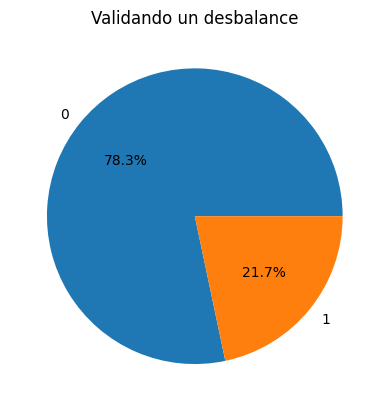

In [29]:
# Contar valores por categoría
counts = train['default_payment_next_month'].value_counts()

plt.figure()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.title('Validando un desbalance')
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Separamos X (variables) y y (lo que queremos predecir)
X = train.drop(['default_payment_next_month','id'], axis=1)
y = train['default_payment_next_month']

# Reservamos el 20% de los datos para el "examen final" (test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


# 3. ESCALAR SOLO LAS COLUMNAS DE MONTOS (RobustScaler)
# Es mejor aplicarlo solo a las columnas numéricas continuas
pay_amt_cols = ['bill_amt1', 'bill_amt2','bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 
                'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'limit_bal']

scaler = RobustScaler()

# Ajustamos en TRAIN y transformamos ambos
X_train[pay_amt_cols] = scaler.fit_transform(X_train[pay_amt_cols])
X_test[pay_amt_cols] = scaler.transform(X_test[pay_amt_cols])

# 4. SELECCIÓN DE VARIABLES CON RANDOM FOREST
# Los árboles no necesitan escalado, pero no les afecta si ya está hecho.
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

# Elegimos variables que aporten más que el promedio
selector = SelectFromModel(rf_selector, threshold='mean', prefit=True)

# Aplicamos el filtro a los datos escalados
X_train_final = selector.transform(X_train)
X_test_final = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print(f"Variables seleccionadas: {list(selected_features)}")


Variables seleccionadas: ['limit_bal', 'age', 'pay_0', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt6']


/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


## Entrenamiento de Modelos Sin Balanced y sin muestras sinteticas

In [31]:
from sklearn.svm import SVC


models_config = {
    'Logistic_Reg': {
        'model': LogisticRegression(max_iter=1000, solver='saga'),
        'params': {
            'C': loguniform(1e-4, 1e2),
            'penalty': ['l2']  # Saga con L2 es estándar
        }
    },
    'Ridge': {
        'model': RidgeClassifier(),
        'params': {
            'alpha': loguniform(1e-3, 1e3)
        }
    },
    'LDA': {
        'model': LinearDiscriminantAnalysis(),
        'params': {
            'solver': ['lsqr', 'eigen'],
            'shrinkage': [None, 'auto'] + list(uniform(0, 1).rvs(5))
        }
    },
    'SGD': {
        'model': SGDClassifier(max_iter=2000),
        'params': {
            'loss': ['log_loss', 'hinge'],
            'penalty': ['elasticnet'],
            'alpha': loguniform(1e-5, 1e-1),
            'l1_ratio': uniform(0, 1)
        }
    },
    'Lasso': {
        'model': LogisticRegression(max_iter=1000, solver='liblinear', penalty='l1'),
        'params': {
            'C': loguniform(1e-4, 1e2)
        }
    }
}

resultados = {}

print("Iniciando búsqueda de hiperparámetros...")
for nombre, config in models_config.items():
    print(f"--- Entrenando {nombre} ---")
    
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=20,
        scoring='f1',
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train_final, y_train)
    
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_final)
    f1 = f1_score(y_test, y_pred)
    
    resultados[nombre] = {
        'objeto': best_model,
        'f1_test': f1,
        'params': search.best_params_
    }
    print(f"Resultado F1: {f1:.4f}\n")





Iniciando búsqueda de hiperparámetros...
--- Entrenando Logistic_Reg ---


/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/libr

Resultado F1: 0.3825

--- Entrenando Ridge ---
Resultado F1: 0.1404

--- Entrenando LDA ---
Resultado F1: 0.3924

--- Entrenando SGD ---


/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 14 is smaller than n_iter=20. Running 14 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Resultado F1: 0.4098

--- Entrenando Lasso ---
Resultado F1: 0.3807



### Evaluacion de los Modelos 

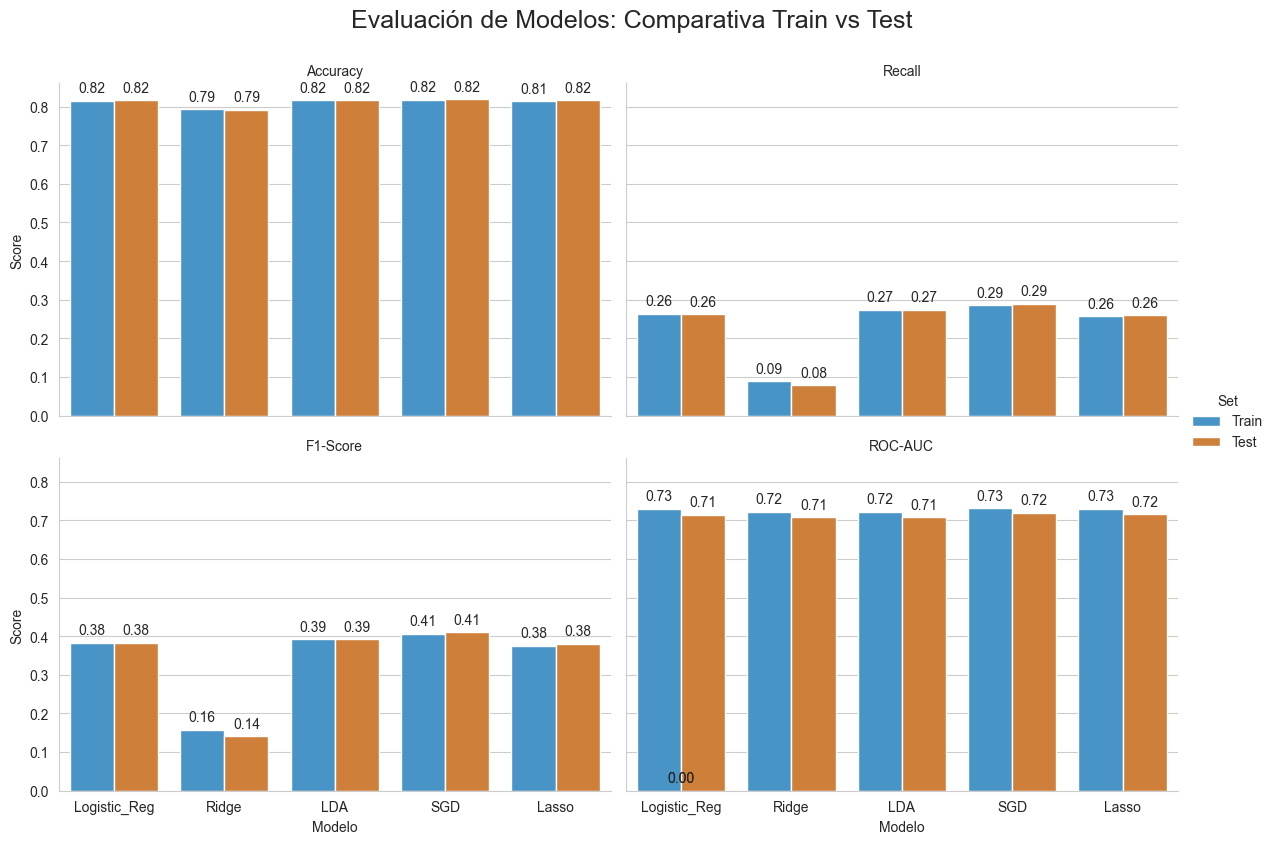

In [32]:
df_metricas_final = evaluar_y_graficar_modelos(resultados, X_train_final, y_train, X_test_final, y_test)

##  Entrenamiento con Balanceo 

In [33]:
models_config = {
    'Logistic_Reg': {
        'model': LogisticRegression(max_iter=1000, solver='saga', class_weight='balanced'),
        'params': {
            'C': loguniform(1e-4, 1e2),
            'penalty': ['l1', 'l2']
        }
    },
    'Ridge': {
        'model': RidgeClassifier(class_weight='balanced'),
        'params': {
            'alpha': loguniform(1e-3, 1e3)
        }
    },
    'LDA': {
        'model': LinearDiscriminantAnalysis(),
        'params': {
            'solver': ['lsqr'],
            'shrinkage': [None, 'auto'] + list(uniform(0, 1).rvs(5))
        }
    },
    'SGD': {
        'model': SGDClassifier(max_iter=2000, class_weight='balanced'),
        'params': {
            'loss': ['log_loss', 'hinge'], 
            'penalty': ['elasticnet'],
            'alpha': loguniform(1e-5, 1e-1),
            'l1_ratio': uniform(0, 1)
        }
    },
    'Lasso': {
        'model': LogisticRegression(max_iter=1000, solver='liblinear', penalty='l1', class_weight='balanced'),
        'params': {
            'C': loguniform(1e-4, 1e2)
        }
    }
}

resultados_balanceados = {}

for nombre, config in models_config.items():
    print(f"--- Entrenando {nombre} (Balanced) ---")
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=30,
        scoring='f1', 
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train_final, y_train)
    
    resultados_balanceados[nombre] = {
        'objeto': search.best_estimator_,
        'f1_test': f1_score(y_test, search.best_estimator_.predict(X_test_final)),
        'params': search.best_params_
    }

df_resumen_balanceados = pd.DataFrame(resultados_balanceados).T.sort_values(by='f1_test', ascending=False)
print(df_resumen_balanceados[['f1_test']])

--- Entrenando Logistic_Reg (Balanced) ---


/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/libr

--- Entrenando Ridge (Balanced) ---
--- Entrenando LDA (Balanced) ---
--- Entrenando SGD (Balanced) ---


/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 7 is smaller than n_iter=30. Running 7 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


--- Entrenando Lasso (Balanced) ---
               f1_test
SGD           0.511368
Lasso         0.490915
Ridge          0.46747
Logistic_Reg  0.455729
LDA           0.392445


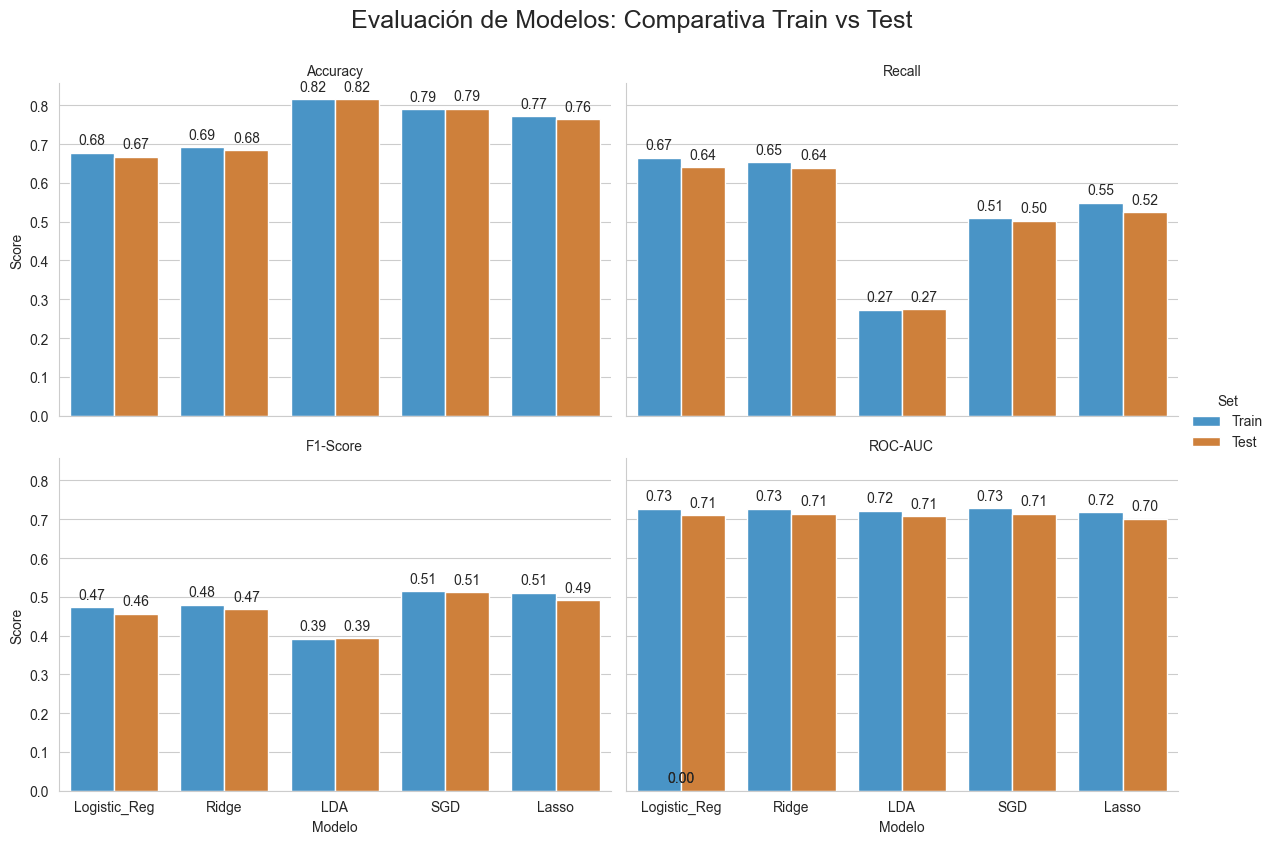

In [34]:
df_metricas_final = evaluar_y_graficar_modelos(resultados_balanceados, X_train_final, y_train, X_test_final, y_test)

## Entremiento con Muestras Sinteticas

In [35]:
models_config = {
    'Logistic_Reg': {
        'model': LogisticRegression(max_iter=1000, solver='saga'),
        'params': {
            'classifier__C': loguniform(1e-4, 1e2),
            'classifier__penalty': ['l1', 'l2']
        }
    },
    'Ridge': {
        'model': RidgeClassifier(),
        'params': {
            'classifier__alpha': loguniform(1e-3, 1e3)
        }
    },
    'LDA': {
        'model': LinearDiscriminantAnalysis(),
        'params': {
            'classifier__solver': ['lsqr'],
            'classifier__shrinkage': [None, 'auto'] + list(uniform(0, 1).rvs(5))
        }
    },
    'SGD': {
        'model': SGDClassifier(max_iter=2000),
        'params': {
            'classifier__loss': ['log_loss', 'hinge'], 
            'classifier__penalty': ['elasticnet'],
            'classifier__alpha': loguniform(1e-5, 1e-1),
            'classifier__l1_ratio': uniform(0, 1)
        }
    },
    'Lasso': {
        'model': LogisticRegression(max_iter=1000, solver='liblinear', penalty='l1'),
        'params': {
            'classifier__C': loguniform(1e-4, 1e2)
        }
    }
}


resultados_sinteticos = {}

for nombre, config in models_config.items():
    print(f"--- Entrenando {nombre} con SMOTE ---")
    

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', config['model'])
    ])
    
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=config['params'],
        n_iter=40,
        scoring='f1', 
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    
    search.fit(X_train_final, y_train)
    

    y_pred = search.best_estimator_.predict(X_test_final)
    
    resultados_sinteticos[nombre] = {
        'objeto': search.best_estimator_,
        'f1_test': f1_score(y_test, y_pred),
        'params': search.best_params_
    }

df_resumen_sinteticos = pd.DataFrame(resultados_sinteticos).T.sort_values(by='f1_test', ascending=False)
print(df_resumen_sinteticos[['f1_test']])

--- Entrenando Logistic_Reg con SMOTE ---


/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/eduardo-castillo/Documentos/diplomado/repositorio/libr

--- Entrenando Ridge con SMOTE ---
--- Entrenando LDA con SMOTE ---


/home/eduardo-castillo/Documentos/diplomado/repositorio/librerias/venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 7 is smaller than n_iter=40. Running 7 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


--- Entrenando SGD con SMOTE ---
--- Entrenando Lasso con SMOTE ---
               f1_test
SGD           0.509104
Logistic_Reg  0.464846
LDA           0.464083
Lasso         0.461808
Ridge         0.461778


### Evaluacion del Modelo 

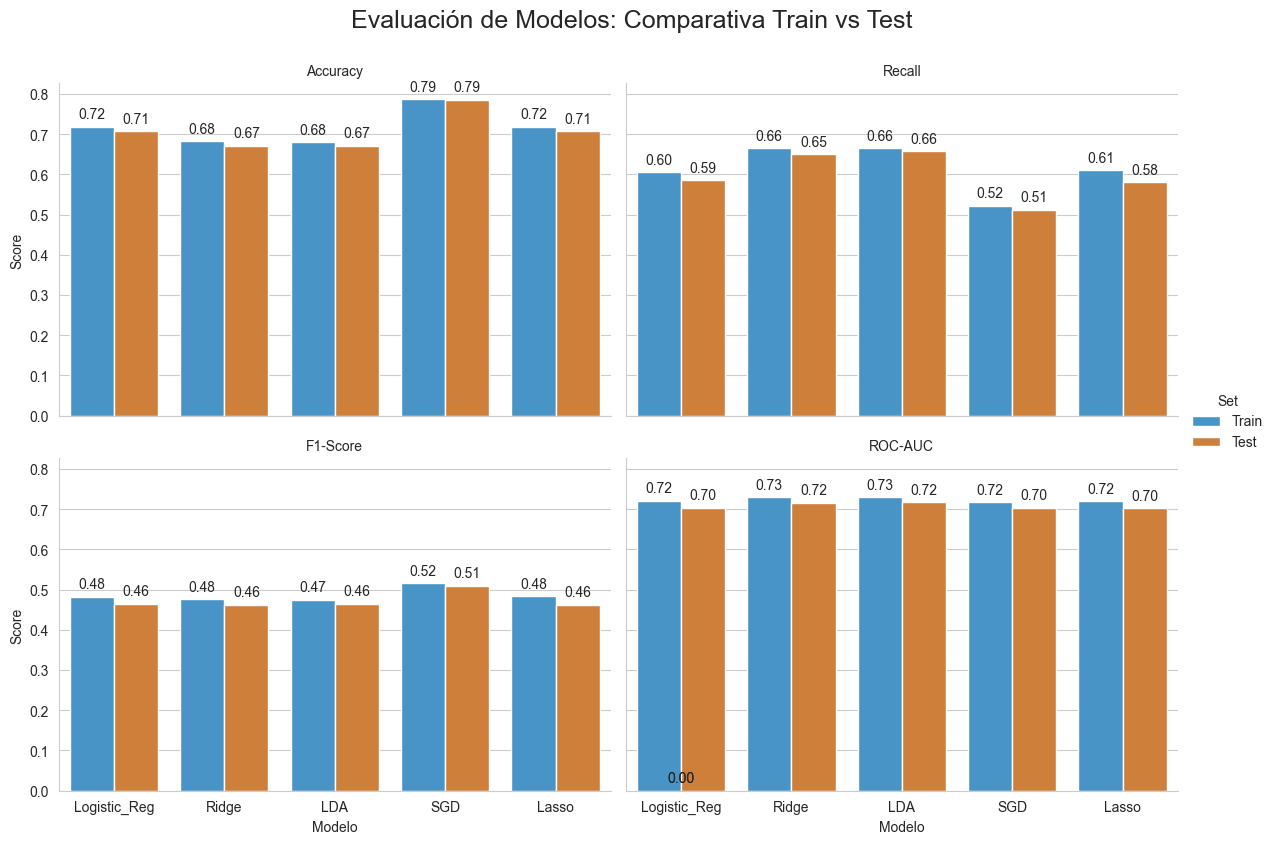

In [36]:
df_metricas_final = evaluar_y_graficar_modelos(resultados_sinteticos, X_train_final, y_train, X_test_final, y_test)

### Seleccionamos el Mejor Modelo 

In [37]:
""" 
    Seleccionamos el mejor de acuerdo a su F1 y a su ROC  
    
    F1 mide el equilibrio entre:

            Precision → cuántos positivos que predices son reales

            Recall → cuántos positivos reales detectas

    F1 alto significa:

        no estoy dejando escapar muchos positivos ni estoy disparando falsas alarmas.


"""

' \n    Seleccionamos el mejor de acuerdo a su F1 y a su ROC  \n\n    F1 mide el equilibrio entre:\n\n            Precision → cuántos positivos que predices son reales\n\n            Recall → cuántos positivos reales detectas\n\n    F1 alto significa:\n\n        no estoy dejando escapar muchos positivos ni estoy disparando falsas alarmas.\n\n\n'

In [38]:
best_name = df_resumen_balanceados.index[0]
best_model = resultados[best_name]['objeto']

print("Modelo ganador:", best_name)
print("Mejores hiperparámetros:", resultados[best_name]['params'])
print("F1 en test:", df_resumen_balanceados.iloc[0]['f1_test'])

Modelo ganador: SGD
Mejores hiperparámetros: {'alpha': np.float64(4.936948694960461e-05), 'l1_ratio': np.float64(0.3910606075732408), 'loss': 'hinge', 'penalty': 'elasticnet'}
F1 en test: 0.511367871785315


In [39]:
import pickle

with open("lasso_balancedo.pkl", "wb") as f:
    pickle.dump(best_model, f)


### Creamos el Pickle y el preprocesamiento

In [42]:
TRAIN_PATH = "train_p3.csv"
TEST_PATH  = "test_p3.csv"
PICKLE_OUT = "CDD_G33_M2_P3_Eduardo_CastilloGarcia.pkl"
PRED_OUT   = "CDD_G33_M2_P3_Eduardo_CastilloGarcia.csv"

ID_COL = "id"
TARGET_COL = "default_payment_next_month"

def normalizar_columnas(df):
    df.columns = (
        df.columns.str.strip().str.lower()
        .map(lambda x: unicodedata.normalize('NFKD', x).encode('ascii', 'ignore').decode('utf-8'))
        .str.replace(r'[^a-z0-9_ ]', '', regex=True).str.replace(' ', '_')
    )
    return df


train_df = pd.read_csv(TRAIN_PATH)
train_df = normalizar_columnas(train_df)

X = train_df.drop([TARGET_COL, ID_COL], axis=1)
y = train_df[TARGET_COL]


pay_amt_cols = ['bill_amt1','bill_amt2','bill_amt3','bill_amt4','bill_amt5','bill_amt6',
                'pay_amt1','pay_amt2','pay_amt3','pay_amt4','pay_amt5','pay_amt6','limit_bal']
other_cols = [c for c in X.columns if c not in pay_amt_cols]


preprocess = ColumnTransformer(transformers=[
    ("robust", RobustScaler(), pay_amt_cols),
    ("rest", "passthrough", other_cols)
])

selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold="mean")


sgd_base = SGDClassifier(
    loss="hinge", # Tu parámetro original
    penalty="elasticnet",
    alpha=4.936948694960461e-05,
    l1_ratio=0.3910606075732408,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)


model_calibrated = CalibratedClassifierCV(sgd_base, method='sigmoid', cv=3)

pipeline_final = ImbPipeline([
    ("preprocess", preprocess),
    ("selector", selector),
    ("smote", SMOTE(random_state=42)),
    ("classifier", model_calibrated)
])

pipeline_final.fit(X, y)

with open(PICKLE_OUT, "wb") as f:
    pickle.dump(pipeline_final, f)


### Implementamos el Pickle 

In [43]:
with open(PICKLE_OUT, "rb") as f:
    modelo_cargado = pickle.load(f)


test_df = pd.read_csv(TEST_PATH)
test_df = normalizar_columnas(test_df)

ids = test_df[ID_COL]
X_test = test_df.drop(ID_COL, axis=1)
y_hat = modelo_cargado.predict_proba(X_test)[:, 1]


pred_df = pd.DataFrame({
    "ID": ids,
    "y_hat": y_hat
})


pred_df.to_csv(PRED_OUT, index=False)

print(f"Archivo de entrega generado: {PRED_OUT}")
print("-" * 30)
print(pred_df.head()) 

Archivo de entrega generado: CDD_G33_M2_P3_Eduardo_CastilloGarcia.csv
------------------------------
      ID     y_hat
0  21256  0.401686
1  14589  0.238299
2  19988  0.429199
3  21287  0.657936
4  12418  0.621688
